In [2]:
import numpy as np
import pandas as pd
from keras.models import load_model
from sklearn.metrics import classification_report, confusion_matrix


In [3]:
model_path = r"C:\Users\21629\Desktop\PFE\modéle (CNN) 1D basée aal mitbih\CNN 1D model.h5"
model = load_model(model_path)
print("Model loaded successfully!")


Model loaded successfully!


In [4]:
test_data_path = r"C:\Users\21629\Desktop\PFE\modéle (CNN) 1D basée aal mitbih\mitbih_test.csv\mitbih_test.csv"
df_test = pd.read_csv(test_data_path, header=None)

Y_test = np.array(df_test[187].values).astype(np.int8)
X_test = np.array(df_test[list(range(187))].values)[..., np.newaxis]


In [5]:
# Faire des prédictions
pred_test = model.predict(X_test)
pred_test = np.argmax(pred_test, axis=-1)

# Afficher le F1-score et l'accuracy
print("Test F1 Score:", classification_report(Y_test, pred_test))
print("Confusion Matrix:\n", confusion_matrix(Y_test, pred_test))


685/685 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step
Test F1 Score:               precision    recall  f1-score   support

           0       0.99      1.00      0.99     18118
           1       0.90      0.81      0.85       556
           2       0.97      0.95      0.96      1448
           3       0.86      0.77      0.81       162
           4       0.99      0.99      0.99      1608

    accuracy                           0.99     21892
   macro avg       0.94      0.90      0.92     21892
weighted avg       0.99      0.99      0.99     21892

Confusion Matrix:
 [[18050    45    15     4     4]
 [   97   451     5     1     2]
 [   44     4  1381    15     4]
 [   23     0    14   125     0]
 [   14     0     2     0  1592]]


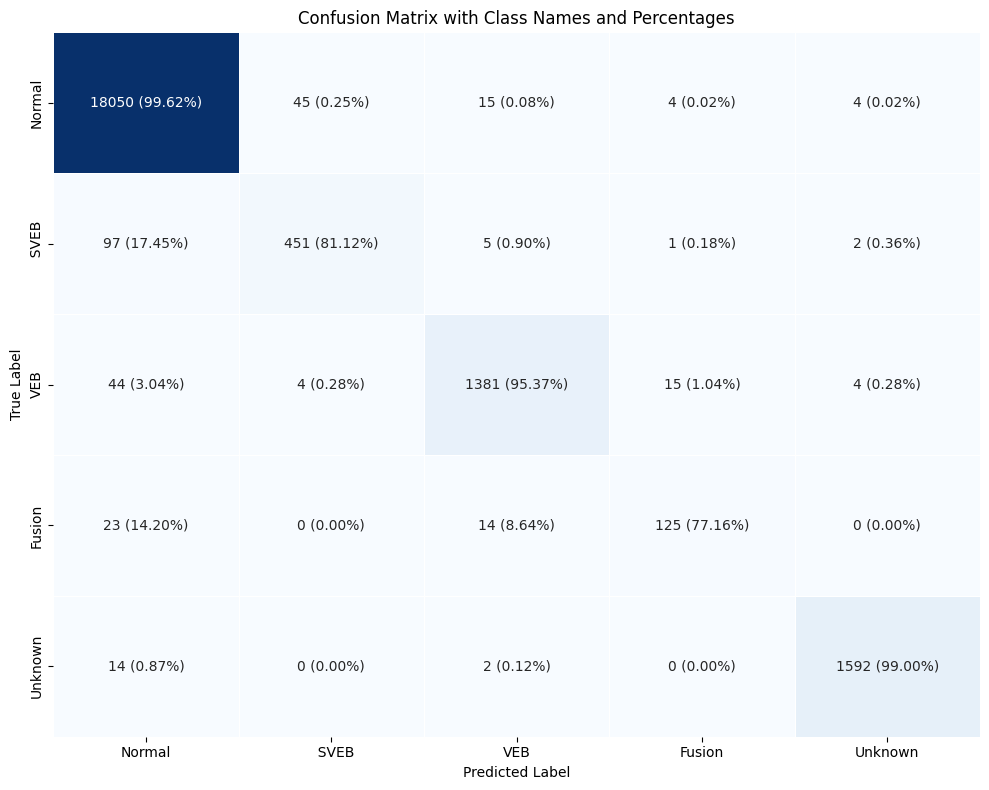

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# Your class names
class_names = ["Normal", "  SVEB", "VEB", "Fusion", "Unknown"]

# Compute confusion matrix
conf_matrix = confusion_matrix(Y_test, pred_test)
cm_percent = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis] * 100

# Create labels with value and percentage
labels = np.array([
    [f"{conf_matrix[i, j]} ({cm_percent[i, j]:.2f}%)" for j in range(conf_matrix.shape[1])]
    for i in range(conf_matrix.shape[0])
])

# Plot
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=labels, fmt="", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names,
            annot_kws={"size": 10}, linewidths=0.5, cbar=False)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix with Class Names and Percentages")
plt.tight_layout()
plt.show()


In [3]:
import pandas as pd
import numpy as np

# Charger les données MIT-BIH
df_test = pd.read_csv(r"C:\Users\21629\Documents\PFA\mitbih_test.csv\mitbih_test.csv", header=None)

# Séparer les features (X) et labels (Y) pour les données de test
Y_test = np.array(df_test[187].values).astype(np.int8)
X_test = np.array(df_test[list(range(187))].values)[..., np.newaxis]


In [5]:
from keras.models import load_model

# Charger ton modèle préalablement enregistré
model = load_model(r"C:\Users\21629\Desktop\PFE\modéle (CNN) 1D basée aal mitbih\baseline_cnn_mitbih.h5")


In [33]:
# Sélectionner un exemple au hasard dans le dataset de test
idx = np.random.randint(0, X_test.shape[0])  # Choisir un index aléatoire
sample_ecg = X_test[idx]  # Récupérer le signal ECG
true_label = Y_test[idx]  # Récupérer la vraie classe

# Faire une prédiction
sample_ecg = np.expand_dims(sample_ecg, axis=0)  # Ajouter une dimension batch
predicted_class = np.argmax(model.predict(sample_ecg), axis=-1)[0]

print(f"Vraie classe: {true_label}")
print(f"Classe prédite: {predicted_class}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
Vraie classe: 0
Classe prédite: 0


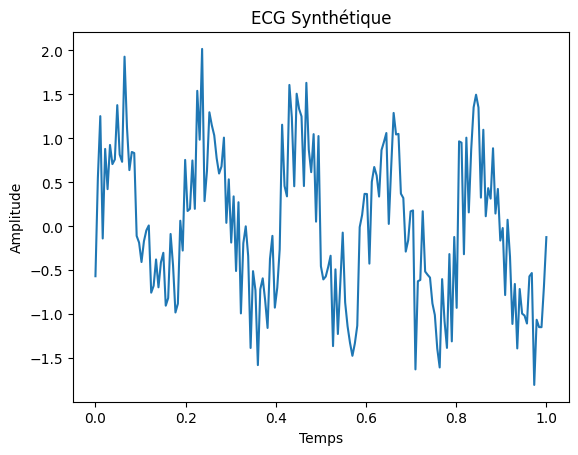

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
Classe prédite pour le signal synthétique: 2


In [37]:
import numpy as np
import matplotlib.pyplot as plt

# Générer un signal sinusoïdal imitant vaguement un ECG
t = np.linspace(0, 1, 187)
synthetic_ecg = np.sin(2 * np.pi * 5 * t)  # Fréquence de 5 Hz
synthetic_ecg += 0.5 * np.random.randn(187)  # Ajouter du bruit

# Afficher le signal
plt.plot(t, synthetic_ecg)
plt.title("ECG Synthétique")
plt.xlabel("Temps")
plt.ylabel("Amplitude")
plt.show()

# Formater pour le modèle
synthetic_ecg = np.expand_dims(synthetic_ecg, axis=(0, -1))  # Ajouter batch et channel

# Prédire la classe
predicted_class = np.argmax(model.predict(synthetic_ecg), axis=-1)[0]

print(f"Classe prédite pour le signal synthétique: {predicted_class}")
